In [15]:
import scipy 
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import os

from dpd_baselines.utils.data_loader import BlackBoxData80Loader
from dpd_baselines.blocks.polynomials import ChebPoly
from dpd_baselines.blocks.delay import Delay
from dpd_baselines.blocks.math import Conj, Sum, Prod
from dpd_baselines.blocks.filters import ComplexFIR

dpd_baseline_path = Path(r'D:\github_projects\dpd-baselines')
os.chdir(dpd_baseline_path)
signal_path = Path(r'data\BlackBoxData_80.mat')

fs = 1.2288e6
data = BlackBoxData80Loader(signal_path, seq_len=2**10)
data.normalize()
BL_coeff = data.apply_bl()
x_t, y_t, _ = data.get_signals()

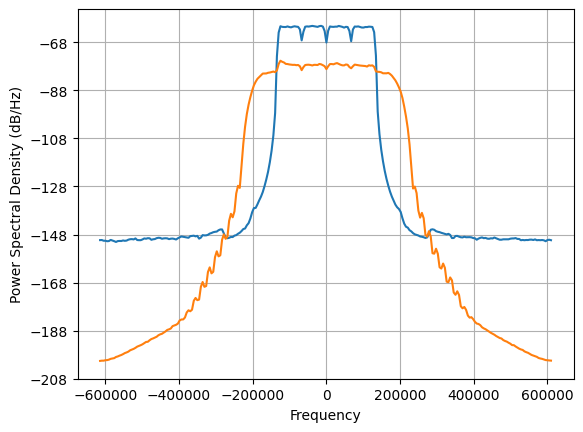

In [2]:
plt.psd(x_t.reshape(-1).to(device='cpu').numpy(), Fs=fs);
plt.psd(y_t.reshape(-1).to(device='cpu').numpy(), Fs=fs);

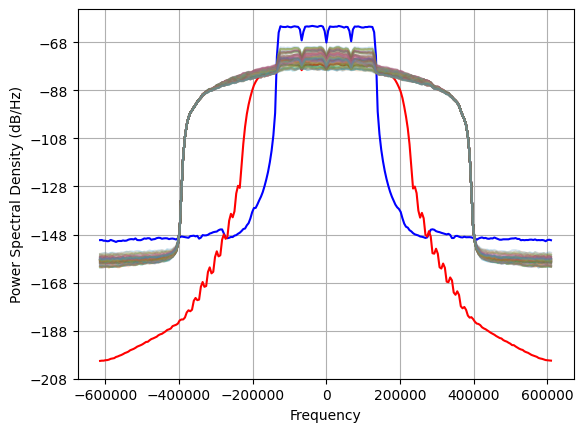

In [3]:
class TermBlock(torch.nn.Module):
    def __init__(self, d1: int, d2: int, order: int):
        super().__init__()
        self.prod = Prod()
        self.delay_sig = Delay(delay=d1)
        self.delay_conj = Delay(delay=d2)
        self.conj = Conj()
        self.poly = ChebPoly(order)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        u = self.prod(x, self.delay_sig(x), self.delay_conj(self.conj(x)))
        return u            

plt.figure()
plt.psd(x_t.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1, c='blue')
plt.psd(y_t.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1, c='red')
with torch.no_grad():
    for d1 in range(-5, 6):
        for d2 in range(-5, 6):
            plt.psd(TermBlock(d1, d2, 5)(x_t).reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=0.2)





In [5]:
import torch
from typing import Sequence

import torch

def _as_feature(x: torch.Tensor) -> torch.Tensor:
    if not isinstance(x, torch.Tensor):
        raise TypeError("x must be torch.Tensor")
    if x.ndim == 2:
        return x.unsqueeze(-1)   # (B,T) -> (B,T,1)
    if x.ndim == 3:
        return x                 # (B,T,K)
    raise ValueError("x must have shape (B,T) or (B,T,K)")

def make_ls_matrix_terms(
    x: torch.Tensor,
    term_blocks: Sequence[torch.nn.Module],
    poly_order: int = 5,
    delays: Sequence[int] = (-2, -1, 0, 1, 2),
):
    if not isinstance(x, torch.Tensor):
        raise TypeError("x must be torch.Tensor")
    if x.ndim != 2:
        raise ValueError("x must have shape (B, T)")
    if not torch.is_complex(x):
        raise TypeError("x must be complex tensor (B, T)")
    poly = ChebPoly(order=poly_order, trainable=False)

    feat_blocks = []
    meta = {
        "columns": [],   # список словарей с описанием каждого блока фич
    }

    # ---------------------------------------------------------
    # 1) poly(delay(x,d)) * x
    # ---------------------------------------------------------
    for d in delays:
        xd = Delay(delay=d)(x)                    # (B, T), complex
        p = poly.feature(xd.abs())                # (B, T, poly_order), real
        block = p * x.unsqueeze(-1)               # (B, T, poly_order), complex
        feat_blocks.append(block)

        for k in range(poly_order):
            meta["columns"].append({
                "kind": "poly(delay(x,d))*x",
                "delay_poly": int(d),
                "poly_idx": int(k),
                "term_idx": None,
            })

    # ---------------------------------------------------------
    # 2) poly(delay(x,d)) * term_j(x)
    # ---------------------------------------------------------
    for j, term in enumerate(term_blocks):
        u = term(x)                               # (B, T), complex

        for d in delays:
            xd = Delay(delay=d)(x)                # (B, T), complex
            p = poly.feature(xd.abs())            # (B, T, poly_order), real
            block = p * u.unsqueeze(-1)           # (B, T, poly_order), complex
            feat_blocks.append(block)

            for k in range(poly_order):
                meta["columns"].append({
                    "kind": "poly(delay(x,d))*term",
                    "delay_poly": int(d),
                    "poly_idx": int(k),
                    "term_idx": int(j),
                })

    if len(feat_blocks) == 0:
        raise ValueError("No feature blocks were generated")

    Phi_btK = torch.cat(feat_blocks, dim=-1)      # (B, T, K)
    Phi = Phi_btK.reshape(-1, Phi_btK.shape[-1])  # (N, K)

    return Phi_btK, Phi, meta

In [18]:
# пример термов (тут задержки внутри терма тоже от -2 до 2)
term_blocks = []
for d1 in range(-1, 1):
    for d2 in range(-1, 1):
        term_blocks.append(TermBlock(d1=d1, d2=d2, order=5))

In [19]:
Phi_btK, Phi, meta = make_ls_matrix_terms(
    x=x_t,                  # (B,T), complex
    term_blocks=term_blocks,
    poly_order=4,
    delays=( -2, -1, 0, 1, 2),
)

def apply_bl_to_Phi_btK_fast(Phi_btK: torch.Tensor, BL_coeff: torch.Tensor) -> torch.Tensor:
    if Phi_btK.ndim != 3:
        raise ValueError("Phi_btK must have shape (B, T, K)")
    if not torch.is_complex(Phi_btK):
        raise TypeError("Phi_btK must be complex tensor")

    B, T, K = Phi_btK.shape
    h = BL_coeff.to(dtype=Phi_btK.dtype, device=Phi_btK.device)

    fir = ComplexFIR(m=h.numel(), coeff=h, trainable=False).to(Phi_btK.device)

    # (B,T,K) -> (B*K, T)
    x = Phi_btK.permute(0, 2, 1).reshape(B * K, T)
    y = fir(x)  # (B*K, T)

    # обратно: (B*K,T) -> (B,T,K)
    Phi_btK_bl = y.reshape(B, K, T).permute(0, 2, 1).contiguous()
    return Phi_btK_bl

# y: (B,T)
Phi_btK = apply_bl_to_Phi_btK_fast(Phi_btK, BL_coeff)
yv = y_t.reshape(-1)

# ridge LS (рекомендую)
lam = 1e-6
K = Phi.shape[1]
A = Phi.conj().T @ Phi + 1e-3 * torch.eye(K, dtype=Phi.dtype, device=Phi.device)
b = Phi.conj().T @ yv
w = torch.linalg.solve(A, b)

# предсказание
y_hat = (Phi @ w).reshape_as(y_t)

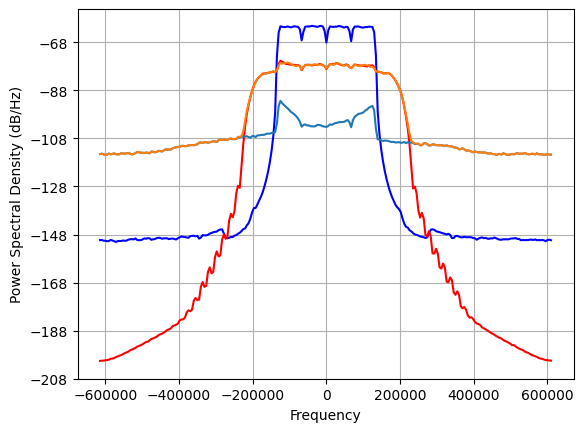

In [20]:
plt.figure()
plt.psd(x_t.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1, c='blue')
plt.psd(y_t.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1, c='red')
plt.psd(y_hat.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1)
plt.psd(y_hat.reshape(-1).to(device='cpu').numpy() - y_t.reshape(-1).to(device='cpu').numpy(), Fs=fs, alpha=1);